# Simple bifurcation example — shortest-path revision

This notebook is a revised version of the simple $\varepsilon$-attracting-basin example for the new terminal-state shortest-path algorithm.

Assumptions of the revised algorithm:

- every sequence has a terminal observation;
- every terminal observation is labelled `good` or `bad`;
- movement forward within the same sequence has cost `0`;
- movement backward within the same sequence is forbidden (`inf`);
- movement between different sequences uses the pairwise cost;
- ordinary $\varepsilon$ uses a minimax/bottleneck path cost;
- $\varepsilon_\Sigma$ uses an additive shortest-path cost.

The original iterative implementation in `epsbasin.py` is not used below.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import anndata as ad

# Make the repository importable whether this notebook is launched from
# the repository root or from the examples directory.
for candidate in (Path.cwd(), Path.cwd().parent):
    if (candidate / "epsbasin").is_dir():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break

import epsbasin
from epsbasin.shortest_path import (
    build_terminal_state_graph,
    eps_attracting_basin_shortest_path,
    eps_sum_attracting_basin_shortest_path,
)

# Optional out-of-sample evaluator added by cross_validation_query.patch.
# A mathematically equivalent fallback is defined below for environments where
# that patch has not yet been applied.
try:
    from epsbasin.shortest_path import minimum_epsilon_to_good_bad
except ImportError:
    minimum_epsilon_to_good_bad = None


## Generate the same type of two-branch time-series data

Only the last observation of each sequence is assigned `good` or `bad`. Intermediate observations are labelled `others`.

In [2]:
def hill_function(x, hill_coef=5, hill_half=2.0):
    x = np.asarray(x, dtype=float)
    return x**hill_coef / (hill_half**hill_coef + x**hill_coef)


def uniform_disk_noise(n, scale, rng):
    radius = scale * np.sqrt(rng.uniform(size=n))
    angle = rng.uniform(0.0, 2.0 * np.pi, size=n)
    return np.column_stack([radius * np.cos(angle), radius * np.sin(angle)])


# Parameters
xlim = [0.0, 2.0]
xdiv = 20
scale = 5.0
hill_coef = 5
hill_half = 2.0
I = 20
noise_scale = 0.1
random_state = 0

rng = np.random.default_rng(random_state)
x = np.linspace(xlim[0], xlim[1], xdiv)
y = hill_function(x, hill_coef=hill_coef, hill_half=hill_half)

base_top = np.column_stack([x, y])
base_bottom = np.column_stack([x, -y])

sequences = []
seq_ids = []
branch_labels = []

seq_id = 0
for branch_name, base in [("top", base_top), ("bottom", base_bottom)]:
    for _ in range(I):
        seq = base + uniform_disk_noise(xdiv, noise_scale, rng)
        sequences.append(scale * seq)
        seq_ids.extend([seq_id] * xdiv)
        branch_labels.extend([branch_name] * xdiv)
        seq_id += 1

data_2d_flat = np.vstack(sequences)
seq_ids = np.asarray(seq_ids, dtype=int)
branch_labels = np.asarray(branch_labels, dtype=object)

cluster = np.full(data_2d_flat.shape[0], "others", dtype=object)
for sid in np.unique(seq_ids):
    idx = np.flatnonzero(seq_ids == sid)
    terminal = idx[-1]
    cluster[terminal] = "good" if data_2d_flat[terminal, 1] > 0 else "bad"

adata = ad.AnnData(X=data_2d_flat)
adata.obs = pd.DataFrame(
    {
        "seq_id": seq_ids,
        "cluster": cluster,
        "branch": branch_labels,
        "x": data_2d_flat[:, 0],
        "y": data_2d_flat[:, 1],
    },
    index=adata.obs_names.copy(),
)

adata


AnnData object with n_obs × n_vars = 800 × 2
    obs: 'seq_id', 'cluster', 'branch', 'x', 'y'

In [3]:
# Confirm that every sequence terminal is labelled good or bad.
terminal_rows = adata.obs.groupby("seq_id", sort=False).tail(1)
print(terminal_rows["cluster"].value_counts())
assert terminal_rows["cluster"].isin(["good", "bad"]).all()


cluster
good    20
bad     20
Name: count, dtype: int64


## Input trajectories

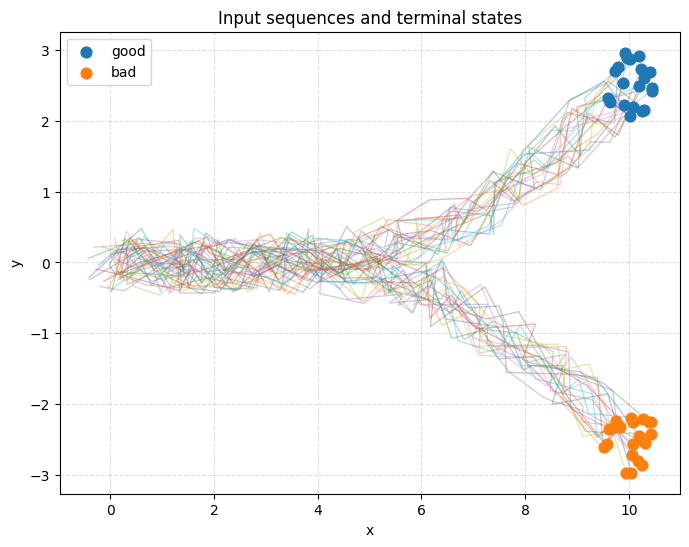

In [4]:
fig, ax = plt.subplots(figsize=(8, 6))

for sid in adata.obs["seq_id"].unique():
    idx = np.flatnonzero(adata.obs["seq_id"].to_numpy() == sid)
    ax.plot(adata.X[idx, 0], adata.X[idx, 1], "-", lw=1, alpha=0.35)

mask_good = adata.obs["cluster"].to_numpy() == "good"
mask_bad = adata.obs["cluster"].to_numpy() == "bad"
ax.scatter(adata.X[mask_good, 0], adata.X[mask_good, 1], s=60, label="good", zorder=5)
ax.scatter(adata.X[mask_bad, 0], adata.X[mask_bad, 1], s=60, label="bad", zorder=5)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Input sequences and terminal states")
ax.grid(ls="--", alpha=0.4)
ax.legend()
plt.show()


## Velocity vectors

The velocity is computed independently within each sequence by central differences, with one-sided differences at the endpoints.

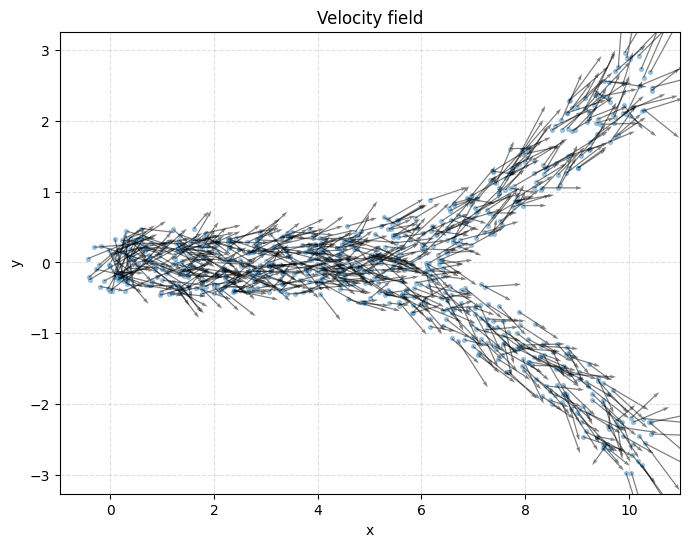

In [5]:
velocity = np.zeros_like(adata.X, dtype=float)

for sid in adata.obs["seq_id"].unique():
    idx = np.flatnonzero(adata.obs["seq_id"].to_numpy() == sid)
    points = np.asarray(adata.X[idx], dtype=float)

    if len(idx) == 1:
        velocity[idx] = 0.0
    elif len(idx) == 2:
        v = points[1] - points[0]
        velocity[idx[0]] = v
        velocity[idx[1]] = v
    else:
        velocity[idx[0]] = points[1] - points[0]
        velocity[idx[-1]] = points[-1] - points[-2]
        velocity[idx[1:-1]] = 0.5 * (points[2:] - points[:-2])

adata.obsm["velocity"] = velocity

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(adata.X[:, 0], adata.X[:, 1], s=8, alpha=0.35)
ax.quiver(
    adata.X[:, 0],
    adata.X[:, 1],
    velocity[:, 0],
    velocity[:, 1],
    angles="xy",
    scale_units="xy",
    scale=1.0,
    width=0.002,
    alpha=0.5,
)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Velocity field")
ax.grid(ls="--", alpha=0.4)
plt.show()


## Build and inspect the directed weighted graph

`sequence_edge_mode="all_forward"` implements the requested rule that every forward pair in the same time series has weight zero, while the reverse direction is infinite.

In [6]:
graph = build_terminal_state_graph(
    adata,
    seq_key="seq_id",
    cluster_key="cluster",
    good_cluster_key="good",
    bad_cluster_key="bad",
    sequence_edge_mode="all_forward",
)

# Sanity check on one sequence.
idx0 = np.flatnonzero(adata.obs["seq_id"].to_numpy() == adata.obs["seq_id"].iloc[0])
print("forward first -> last:", graph.weights[idx0[0], idx0[-1]])
print("reverse last -> first:", graph.weights[idx0[-1], idx0[0]])
print("number of terminal states:", len(graph.terminal_indices))


forward first -> last: 0.0
reverse last -> first: inf
number of terminal states: 40


## New $\varepsilon$ debut functions: minimax shortest paths

For a path $P$, the path cost is

$$
\min_P \max_{e \in P} w(e).
$$

Good and Bad debut functions are computed together because every terminal state belongs to exactly one of the two terminal classes.

In [7]:
eps_attracting_basin_shortest_path(
    adata,
    seq_key="seq_id",
    cluster_key="cluster",
    good_cluster_key="good",
    bad_cluster_key="bad",
    cost_matrix_key="cost_matrix",
    sequence_edge_mode="all_forward",
    output_key="eps_attracting_basin_sp",
    distance_key="eps_distance_sp",
    terminal_class_key="terminal_class",
    store_next_hop=True,
)

adata.obs[[
    "cluster",
    "terminal_class",
    "eps_attracting_basin_sp_good",
    "eps_attracting_basin_sp_bad",
    "eps_attracting_basin_sp_landscape",
]].head()


,cluster,terminal_class,eps_attracting_basin_sp_good,eps_attracting_basin_sp_bad,eps_attracting_basin_sp_landscape
0,others,good,-0.021629,0.021629,-0.021629
1,others,good,-0.021629,0.021629,-0.021629
2,others,good,-0.021629,0.021629,-0.021629
3,others,good,-0.021629,0.021629,-0.021629
4,others,good,-0.021629,0.021629,-0.021629


## New $\varepsilon_\Sigma$ debut functions: additive shortest paths

For a path $P$, the path cost is

$$
\min_P \sum_{e \in P} w(e).
$$

In [8]:
eps_sum_attracting_basin_shortest_path(
    adata,
    seq_key="seq_id",
    cluster_key="cluster",
    good_cluster_key="good",
    bad_cluster_key="bad",
    cost_matrix_key="cost_matrix",
    sequence_edge_mode="all_forward",
    output_key="eps_sum_attracting_basin_sp",
    distance_key="eps_sum_distance_sp",
)

adata.obs[[
    "cluster",
    "eps_sum_attracting_basin_sp_good",
    "eps_sum_attracting_basin_sp_bad",
    "eps_sum_attracting_basin_sp_landscape",
]].head()


,cluster,eps_sum_attracting_basin_sp_good,eps_sum_attracting_basin_sp_bad,eps_sum_attracting_basin_sp_landscape
0,others,-0.021629,0.021629,-0.021629
1,others,-0.021629,0.021629,-0.021629
2,others,-0.021629,0.021629,-0.021629
3,others,-0.021629,0.021629,-0.021629
4,others,-0.021629,0.021629,-0.021629


## Debut functions for $\varepsilon$

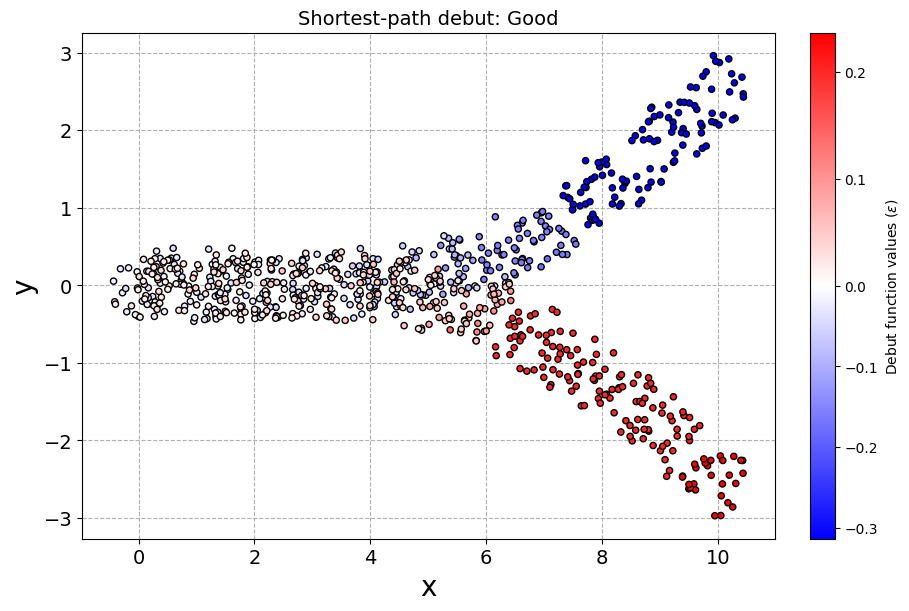

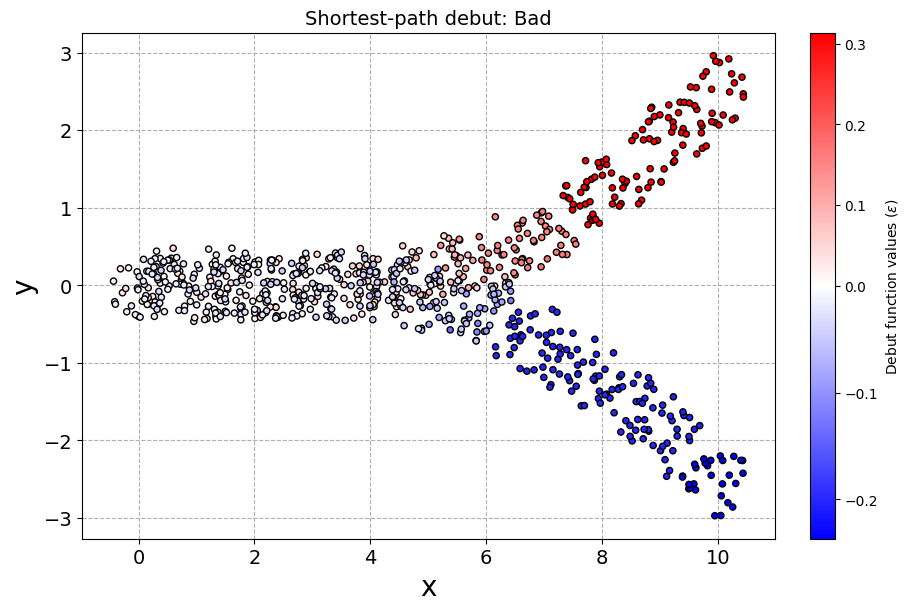

In [9]:
epsbasin.plot_debut(
    adata,
    eps_key="eps_attracting_basin_sp",
    target_cluster_key="good",
    title="Shortest-path debut: Good",
)

epsbasin.plot_debut(
    adata,
    eps_key="eps_attracting_basin_sp",
    target_cluster_key="bad",
    title="Shortest-path debut: Bad",
)


## Debut functions for $\varepsilon_\Sigma$

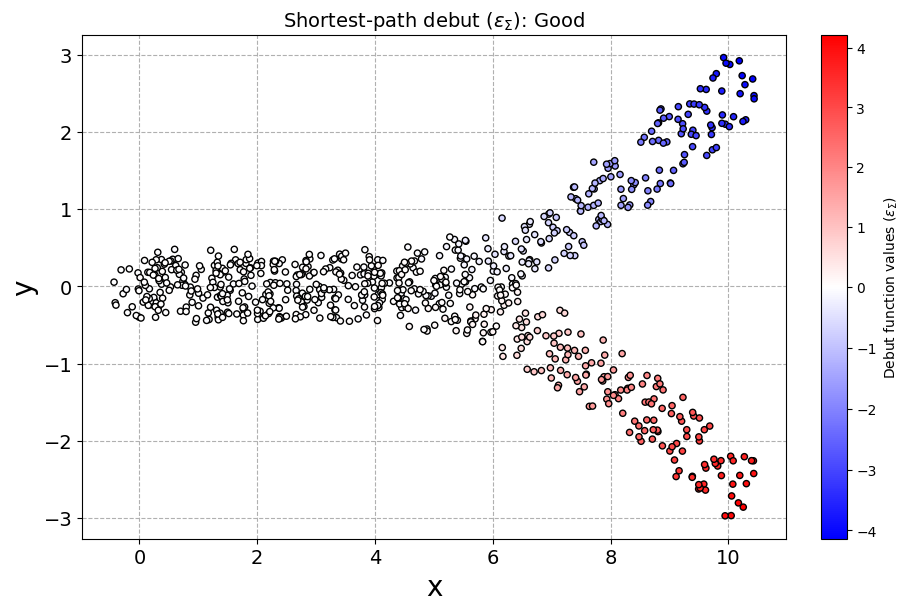

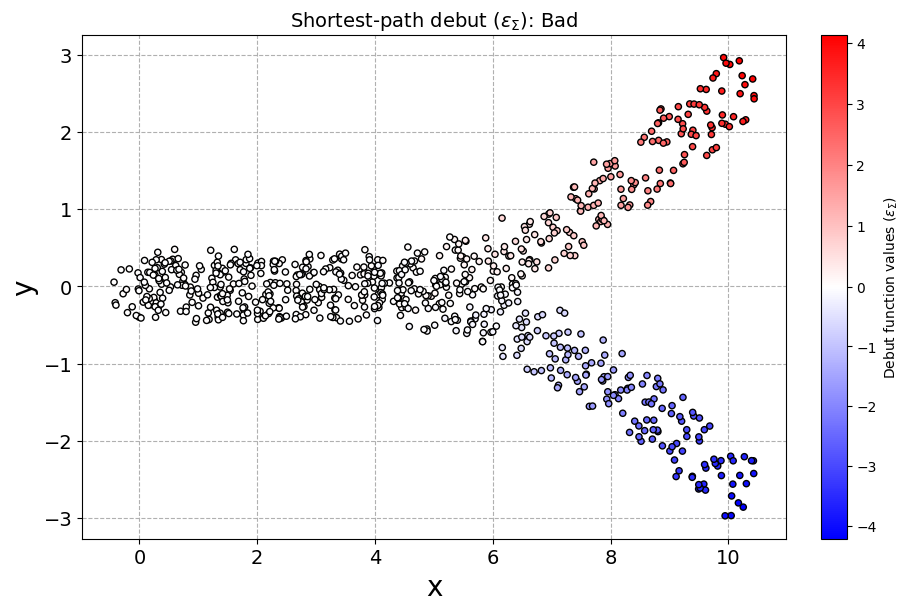

In [10]:
epsbasin.plot_debut(
    adata,
    eps_key="eps_sum_attracting_basin_sp",
    target_cluster_key="good",
    title=r"Shortest-path debut ($\varepsilon_\Sigma$): Good",
)

epsbasin.plot_debut(
    adata,
    eps_key="eps_sum_attracting_basin_sp",
    target_cluster_key="bad",
    title=r"Shortest-path debut ($\varepsilon_\Sigma$): Bad",
)


## Landscape

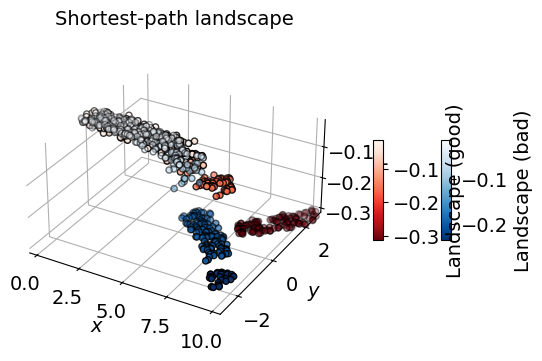

In [11]:
epsbasin.plot_landscape(
    adata,
    eps_key="eps_attracting_basin_sp",
    target_cluster_keys=["good", "bad"],
    figsize=(10, 10),
    show_title=True,
    title="Shortest-path landscape",
)


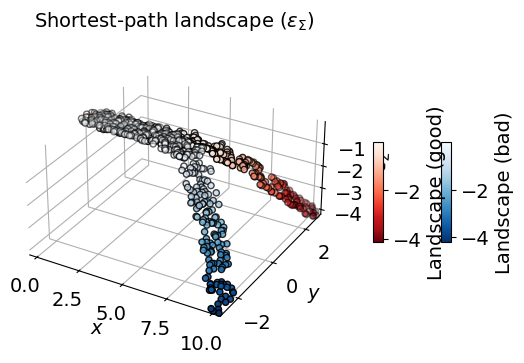

In [12]:
epsbasin.plot_landscape(
    adata,
    eps_key="eps_sum_attracting_basin_sp",
    target_cluster_keys=["good", "bad"],
    figsize=(10, 10),
    show_title=True,
    title=r"Shortest-path landscape ($\varepsilon_\Sigma$)",
)


## Attracting-basin visualization at a selected threshold

The old plotting function can be reused because the new implementation writes Good/Bad debut functions using the same `<eps_key>_good` / `<eps_key>_bad` naming convention.

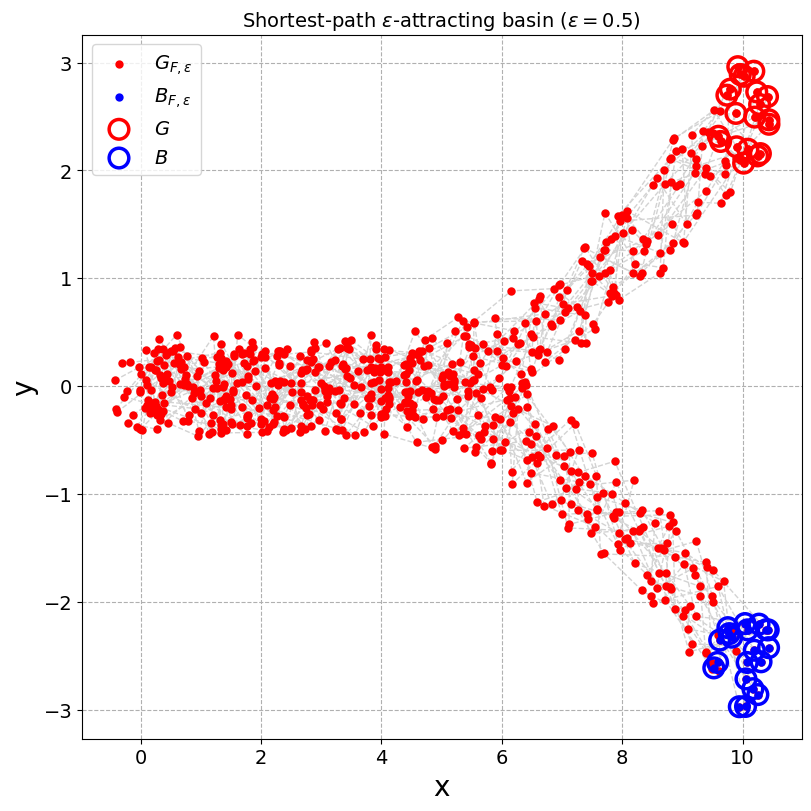

In [13]:
eps_threshold = 0.5

epsbasin.plot_attracting_basin(
    adata,
    eps_key="eps_attracting_basin_sp",
    cluster_key="cluster",
    good_cluster_key="good",
    bad_cluster_key="bad",
    eps_threshold=eps_threshold,
    figsize=(8, 8),
    title=rf"Shortest-path $\varepsilon$-attracting basin ($\varepsilon={eps_threshold}$)",
)


## Basic consistency checks

In [14]:
# Each observation inherits the natural terminal class of its own sequence.
for sid in adata.obs["seq_id"].unique():
    idx = np.flatnonzero(adata.obs["seq_id"].to_numpy() == sid)
    natural_terminal = adata.obs["cluster"].iloc[idx[-1]]
    assert np.all(adata.obs["terminal_class"].iloc[idx].to_numpy() == natural_terminal)

# The two signed debut functions are complementary under the Good/Bad terminal partition.
np.testing.assert_allclose(
    adata.obs["eps_attracting_basin_sp_good"].to_numpy(),
    -adata.obs["eps_attracting_basin_sp_bad"].to_numpy(),
)
np.testing.assert_allclose(
    adata.obs["eps_sum_attracting_basin_sp_good"].to_numpy(),
    -adata.obs["eps_sum_attracting_basin_sp_bad"].to_numpy(),
)

print("All consistency checks passed.")


All consistency checks passed.


## Leave-one-sequence-out cross-validation

This section performs **leave-one-sequence-out (LOSO) cross-validation**.
For each `seq_id`, the complete trajectory is removed from the training set.
The Good/Bad debut functions are reconstructed using only the remaining
trajectories.  Then every state $x$ in the held-out trajectory is connected to
the training graph using only the supplied costs $c(x, X_i)$.

For the ordinary $\varepsilon$ (bottleneck) case,

$$
\varepsilon_G(x)=\min_i\max\{c(x,X_i), d_G(X_i)\},\qquad
\varepsilon_B(x)=\min_i\max\{c(x,X_i), d_B(X_i)\}.
$$

The prediction is `good` when $\varepsilon_G(x)<\varepsilon_B(x)$ and `bad`
when the reverse inequality holds.  A tie is kept explicitly as `tie`.

The terminal label of the held-out sequence is used only as the test label; it
is never included in the training graph.

In [15]:
from dataclasses import dataclass


@dataclass(frozen=True)
class _ExternalStateEpsilonFallback:
    epsilon_good: float
    epsilon_bad: float
    entry_index_good: int
    entry_index_bad: int
    path_cost: str
    good_cluster_key: str
    bad_cluster_key: str


def _minimum_epsilon_to_good_bad_fallback(
    adata_train,
    x,
    costs,
    *,
    output_key="eps_attracting_basin_sp",
):
    """Notebook-local equivalent of minimum_epsilon_to_good_bad()."""
    params_key = f"{output_key}_params"
    if params_key not in adata_train.uns:
        raise KeyError(
            f"{params_key!r} is missing. Compute the shortest-path debut "
            "functions on the training data first."
        )

    params = adata_train.uns[params_key]
    path_cost = params["path_cost"]
    good_key = params.get("good_cluster_key", "good")
    bad_key = params.get("bad_cluster_key", "bad")

    x = np.asarray(x, dtype=float).reshape(-1)
    costs = np.asarray(costs, dtype=float).reshape(-1)

    if x.shape[0] != adata_train.X.shape[1]:
        raise ValueError("x has a different dimension from adata_train.X.")
    if costs.shape[0] != adata_train.n_obs:
        raise ValueError("costs must contain one value per training sample.")
    if np.isnan(costs).any() or np.any(costs[np.isfinite(costs)] < 0):
        raise ValueError("costs must be non-negative and may not contain NaN.")

    # Under the Good/Bad terminal partition, the non-negative distance to a
    # target class is the positive part of its signed debut function.
    d_good = np.maximum(
        adata_train.obs[f"{output_key}_{good_key}"].to_numpy(dtype=float),
        0.0,
    )
    d_bad = np.maximum(
        adata_train.obs[f"{output_key}_{bad_key}"].to_numpy(dtype=float),
        0.0,
    )

    if path_cost == "max":
        candidate_good = np.maximum(costs, d_good)
        candidate_bad = np.maximum(costs, d_bad)
    elif path_cost == "sum":
        candidate_good = costs + d_good
        candidate_bad = costs + d_bad
    else:
        raise ValueError(f"Unknown path_cost: {path_cost!r}")

    eps_good = float(np.min(candidate_good))
    eps_bad = float(np.min(candidate_bad))

    return _ExternalStateEpsilonFallback(
        epsilon_good=eps_good,
        epsilon_bad=eps_bad,
        entry_index_good=-1 if np.isinf(eps_good) else int(np.argmin(candidate_good)),
        entry_index_bad=-1 if np.isinf(eps_bad) else int(np.argmin(candidate_bad)),
        path_cost=path_cost,
        good_cluster_key=good_key,
        bad_cluster_key=bad_key,
    )


def evaluate_external_state(adata_train, x, costs, *, output_key):
    """Use the package function when available, otherwise use the fallback."""
    if minimum_epsilon_to_good_bad is not None:
        return minimum_epsilon_to_good_bad(
            adata_train,
            x,
            costs,
            output_key=output_key,
        )
    return _minimum_epsilon_to_good_bad_fallback(
        adata_train,
        x,
        costs,
        output_key=output_key,
    )


print(
    "Out-of-sample evaluator:",
    "epsbasin.shortest_path.minimum_epsilon_to_good_bad"
    if minimum_epsilon_to_good_bad is not None
    else "notebook fallback",
)

Out-of-sample evaluator: notebook fallback


In [16]:
def leave_one_sequence_out_cv(
    adata_full,
    *,
    path_cost="max",
    seq_key="seq_id",
    cluster_key="cluster",
    good_cluster_key="good",
    bad_cluster_key="bad",
    cost_matrix_key="cost_matrix",
    sequence_edge_mode="all_forward",
    tie_tol=1e-12,
    verbose=True,
):
    """Leave one complete trajectory out and predict every held-out state.

    Parameters
    ----------
    adata_full
        AnnData containing all trajectories.  Every trajectory terminal must be
        labelled Good or Bad.
    path_cost
        "max" for ordinary epsilon, "sum" for epsilon_Sigma.

    Returns
    -------
    pandas.DataFrame
        One row per held-out state with Good/Bad epsilon, prediction, margin,
        and the optimal first training vertex for each target class.
    """
    if path_cost not in {"max", "sum"}:
        raise ValueError("path_cost must be 'max' or 'sum'.")

    seq_values = adata_full.obs[seq_key].to_numpy()
    all_indices = np.arange(adata_full.n_obs)
    seq_ids = list(pd.unique(seq_values))

    # The raw cost matrix is the cost between observations, before replacing
    # same-sequence forward edges by zero in the directed training graph.
    if cost_matrix_key in adata_full.uns:
        full_cost = np.asarray(adata_full.uns[cost_matrix_key], dtype=float)
    else:
        from sklearn.metrics import pairwise_distances
        full_cost = pairwise_distances(adata_full.X)

    if full_cost.shape != (adata_full.n_obs, adata_full.n_obs):
        raise ValueError("The full cost matrix has an incompatible shape.")

    rows = []

    for fold, heldout_seq in enumerate(seq_ids, start=1):
        test_indices = all_indices[seq_values == heldout_seq]
        train_indices = all_indices[seq_values != heldout_seq]

        # Entire held-out sequence, including its terminal label, is removed.
        adata_train = adata_full[train_indices].copy()
        adata_train.uns[cost_matrix_key] = full_cost[np.ix_(train_indices, train_indices)].copy()

        if path_cost == "max":
            output_key = "cv_eps_attracting_basin_sp"
            eps_attracting_basin_shortest_path(
                adata_train,
                seq_key=seq_key,
                cluster_key=cluster_key,
                good_cluster_key=good_cluster_key,
                bad_cluster_key=bad_cluster_key,
                cost_matrix_key=cost_matrix_key,
                sequence_edge_mode=sequence_edge_mode,
                output_key=output_key,
            )
        else:
            output_key = "cv_eps_sum_attracting_basin_sp"
            eps_sum_attracting_basin_shortest_path(
                adata_train,
                seq_key=seq_key,
                cluster_key=cluster_key,
                good_cluster_key=good_cluster_key,
                bad_cluster_key=bad_cluster_key,
                cost_matrix_key=cost_matrix_key,
                sequence_edge_mode=sequence_edge_mode,
                output_key=output_key,
            )

        # The held-out trajectory label is its terminal label.  This is only
        # consulted after fitting the training graph.
        true_label = str(adata_full.obs.iloc[test_indices[-1]][cluster_key])
        if true_label not in {good_cluster_key, bad_cluster_key}:
            raise ValueError(
                f"Held-out sequence {heldout_seq!r} does not terminate in "
                f"{good_cluster_key!r} or {bad_cluster_key!r}."
            )

        for step, global_index in enumerate(test_indices):
            x_query = np.asarray(adata_full.X[global_index], dtype=float).reshape(-1)
            costs_x_to_train = full_cost[global_index, train_indices]

            result = evaluate_external_state(
                adata_train,
                x_query,
                costs_x_to_train,
                output_key=output_key,
            )

            margin_good = result.epsilon_bad - result.epsilon_good
            if margin_good > tie_tol:
                prediction = good_cluster_key
            elif margin_good < -tie_tol:
                prediction = bad_cluster_key
            else:
                prediction = "tie"

            entry_good_local = result.entry_index_good
            entry_bad_local = result.entry_index_bad
            entry_good_global = (
                -1 if entry_good_local < 0 else int(train_indices[entry_good_local])
            )
            entry_bad_global = (
                -1 if entry_bad_local < 0 else int(train_indices[entry_bad_local])
            )

            rows.append(
                {
                    "path_cost": path_cost,
                    "seq_id": heldout_seq,
                    "step": step,
                    "fraction": 0.0 if len(test_indices) == 1 else step / (len(test_indices) - 1),
                    "global_index": int(global_index),
                    "x": float(adata_full.X[global_index, 0]),
                    "y": float(adata_full.X[global_index, 1]),
                    "true_label": true_label,
                    "epsilon_good": result.epsilon_good,
                    "epsilon_bad": result.epsilon_bad,
                    "margin_good": margin_good,
                    "prediction": prediction,
                    "correct": prediction == true_label,
                    "entry_good_global_index": entry_good_global,
                    "entry_bad_global_index": entry_bad_global,
                    "entry_good_seq_id": (
                        None if entry_good_global < 0
                        else adata_full.obs.iloc[entry_good_global][seq_key]
                    ),
                    "entry_bad_seq_id": (
                        None if entry_bad_global < 0
                        else adata_full.obs.iloc[entry_bad_global][seq_key]
                    ),
                }
            )

        if verbose:
            print(f"[{fold:02d}/{len(seq_ids):02d}] held out seq_id={heldout_seq!r}")

    return pd.DataFrame(rows)

### Run LOSO-CV for ordinary $\varepsilon$

This recomputes the training debut functions for every held-out trajectory, so
no state from the test trajectory is used to construct that fold's landscape.

In [17]:
cv_eps = leave_one_sequence_out_cv(
    adata,
    path_cost="max",
    seq_key="seq_id",
    cluster_key="cluster",
    good_cluster_key="good",
    bad_cluster_key="bad",
    cost_matrix_key="cost_matrix",
    sequence_edge_mode="all_forward",
    verbose=True,
)

cv_eps.head(10)

[01/40] held out seq_id=np.int64(0)
[02/40] held out seq_id=np.int64(1)
[03/40] held out seq_id=np.int64(2)
[04/40] held out seq_id=np.int64(3)
[05/40] held out seq_id=np.int64(4)
[06/40] held out seq_id=np.int64(5)
[07/40] held out seq_id=np.int64(6)
[08/40] held out seq_id=np.int64(7)
[09/40] held out seq_id=np.int64(8)
[10/40] held out seq_id=np.int64(9)
[11/40] held out seq_id=np.int64(10)
[12/40] held out seq_id=np.int64(11)
[13/40] held out seq_id=np.int64(12)
[14/40] held out seq_id=np.int64(13)
[15/40] held out seq_id=np.int64(14)
[16/40] held out seq_id=np.int64(15)
[17/40] held out seq_id=np.int64(16)
[18/40] held out seq_id=np.int64(17)
[19/40] held out seq_id=np.int64(18)
[20/40] held out seq_id=np.int64(19)
[21/40] held out seq_id=np.int64(20)
[22/40] held out seq_id=np.int64(21)
[23/40] held out seq_id=np.int64(22)
[24/40] held out seq_id=np.int64(23)
[25/40] held out seq_id=np.int64(24)
[26/40] held out seq_id=np.int64(25)
[27/40] held out seq_id=np.int64(26)
[28/40] hel

,path_cost,seq_id,step,fraction,global_index,x,y,true_label,epsilon_good,epsilon_bad,margin_good,prediction,correct,entry_good_global_index,entry_bad_global_index,entry_good_seq_id,entry_bad_seq_id
0,max,0,0,0.000000,0,0.392749,0.070632,good,0.045768,0.045768,0.000000,tie,False,160,160,8,8
1,max,0,1,0.052632,1,0.710780,0.182812,good,0.043444,0.043444,0.000000,tie,False,101,101,5,5
2,max,0,2,0.105263,2,1.004222,-0.088817,good,0.059007,0.059007,0.000000,tie,False,782,782,39,39
3,max,0,3,0.157895,3,1.540252,-0.050838,good,0.021054,0.041222,0.020168,good,True,263,263,13,13
4,max,0,4,0.210526,4,1.767755,-0.296941,good,0.028956,0.021629,-0.007327,bad,False,503,503,25,25
5,max,0,5,0.263158,5,2.275895,0.325172,good,0.021947,0.021947,0.000000,tie,False,724,724,36,36
6,max,0,6,0.315789,6,3.547269,0.008826,good,0.104101,0.104101,0.000000,tie,False,187,187,9,9
7,max,0,7,0.368421,7,4.108171,-0.017590,good,0.057607,0.057607,0.000000,tie,False,628,628,31,31
8,max,0,8,0.421053,8,4.065269,-0.273527,good,0.030749,0.044773,0.014024,good,True,108,108,5,5
9,max,0,9,0.473684,9,4.453780,-0.275514,good,0.059292,0.059292,0.000000,tie,False,368,368,18,18


### Terminal-state prediction accuracy

The last state of each held-out trajectory is one independent terminal
prediction.  `accuracy_all` counts ties as incorrect; `accuracy_resolved`
reports accuracy only among non-tied predictions.

In [18]:
terminal_cv = (
    cv_eps.sort_values(["seq_id", "step"])
    .groupby("seq_id", sort=False)
    .tail(1)
    .reset_index(drop=True)
)

accuracy_all = terminal_cv["correct"].mean()
resolved = terminal_cv["prediction"] != "tie"
accuracy_resolved = (
    terminal_cv.loc[resolved, "correct"].mean() if resolved.any() else np.nan
)
tie_rate = (~resolved).mean()

print(f"terminal accuracy (ties incorrect): {accuracy_all:.3f}")
print(f"terminal accuracy (resolved only):  {accuracy_resolved:.3f}")
print(f"terminal tie rate:                  {tie_rate:.3f}")

display(terminal_cv[[
    "seq_id",
    "true_label",
    "epsilon_good",
    "epsilon_bad",
    "margin_good",
    "prediction",
    "correct",
]])

terminal accuracy (ties incorrect): 1.000
terminal accuracy (resolved only):  1.000
terminal tie rate:                  0.000


,seq_id,true_label,epsilon_good,epsilon_bad,margin_good,prediction,correct
0,0,good,0.079574,0.313776,0.234202,good,True
1,1,good,0.225839,0.313776,0.087937,good,True
2,2,good,0.150477,0.313776,0.163299,good,True
3,3,good,0.126064,0.313776,0.187713,good,True
4,4,good,0.060187,0.313776,0.253589,good,True
5,5,good,0.041265,0.327959,0.286694,good,True
6,6,good,0.041265,0.327604,0.286339,good,True
7,7,good,0.051427,0.313776,0.262350,good,True
8,8,good,0.066509,0.313776,0.247267,good,True
9,9,good,0.079574,0.313776,0.234202,good,True


### Prediction accuracy along the trajectory

This shows when the eventual terminal class becomes distinguishable as the
held-out trajectory progresses.

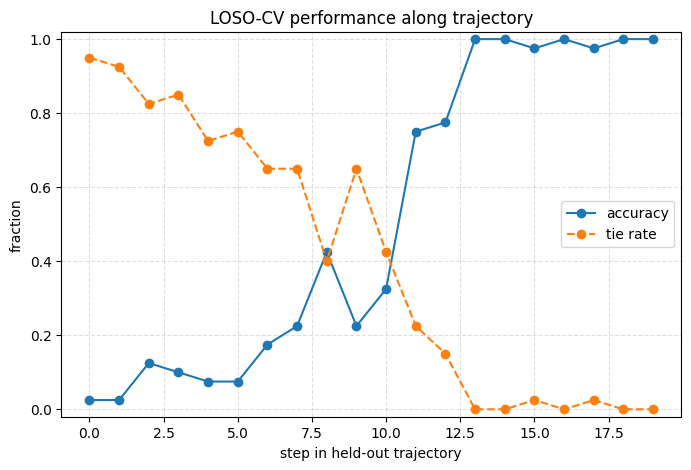

,step,accuracy,tie_rate,mean_fraction
0,0,0.025,0.950,0.000000
1,1,0.025,0.925,0.052632
2,2,0.125,0.825,0.105263
3,3,0.100,0.850,0.157895
4,4,0.075,0.725,0.210526
5,5,0.075,0.750,0.263158
6,6,0.175,0.650,0.315789
7,7,0.225,0.650,0.368421
8,8,0.425,0.400,0.421053
9,9,0.225,0.650,0.473684


In [19]:
accuracy_by_step = (
    cv_eps.groupby("step", as_index=False)
    .agg(
        accuracy=("correct", "mean"),
        tie_rate=("prediction", lambda s: np.mean(s == "tie")),
        mean_fraction=("fraction", "mean"),
    )
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(accuracy_by_step["step"], accuracy_by_step["accuracy"], "o-", label="accuracy")
ax.plot(accuracy_by_step["step"], accuracy_by_step["tie_rate"], "o--", label="tie rate")
ax.set_ylim(-0.02, 1.02)
ax.set_xlabel("step in held-out trajectory")
ax.set_ylabel("fraction")
ax.set_title("LOSO-CV performance along trajectory")
ax.grid(ls="--", alpha=0.4)
ax.legend()
plt.show()

accuracy_by_step

### $\varepsilon_G$ and $\varepsilon_B$ for representative held-out trajectories

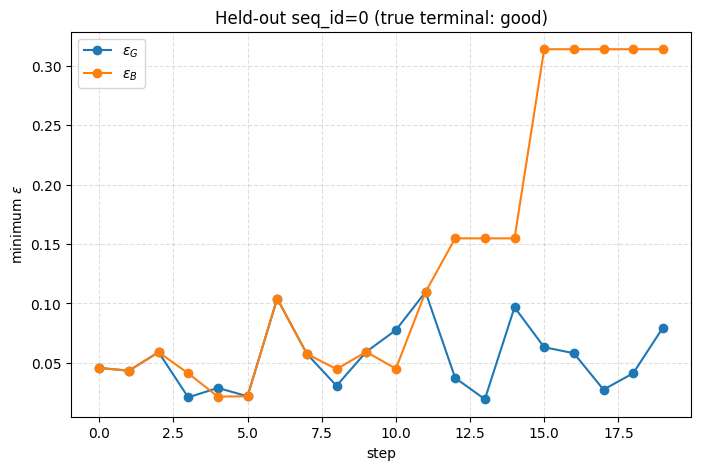

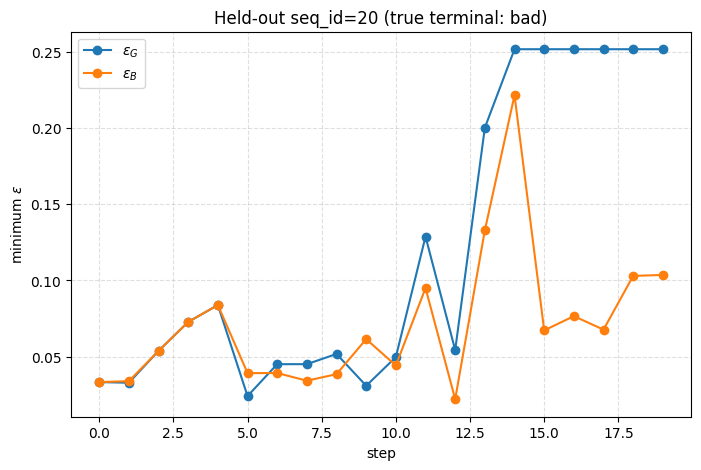

In [20]:
example_good_seq = terminal_cv.loc[
    terminal_cv["true_label"] == "good", "seq_id"
].iloc[0]
example_bad_seq = terminal_cv.loc[
    terminal_cv["true_label"] == "bad", "seq_id"
].iloc[0]

for sid in [example_good_seq, example_bad_seq]:
    df = cv_eps[cv_eps["seq_id"] == sid].sort_values("step")
    label = df["true_label"].iloc[0]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(df["step"], df["epsilon_good"], "o-", label=r"$\varepsilon_G$")
    ax.plot(df["step"], df["epsilon_bad"], "o-", label=r"$\varepsilon_B$")
    ax.set_xlabel("step")
    ax.set_ylabel(r"minimum $\varepsilon$")
    ax.set_title(f"Held-out seq_id={sid} (true terminal: {label})")
    ax.grid(ls="--", alpha=0.4)
    ax.legend()
    plt.show()

### Cross-validated Good/Bad margin in state space

We define

$$
M(x)=\varepsilon_B(x)-\varepsilon_G(x).
$$

Positive values favor Good and negative values favor Bad.

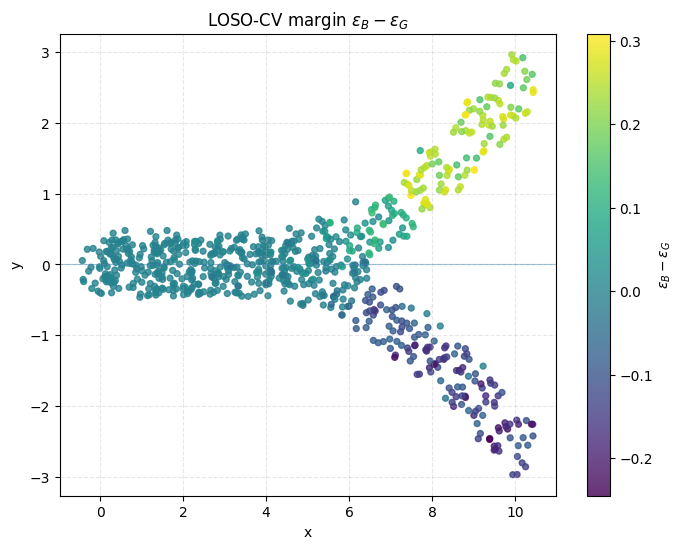

In [21]:
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(
    cv_eps["x"],
    cv_eps["y"],
    c=cv_eps["margin_good"],
    s=18,
    alpha=0.8,
)
ax.axhline(0.0, lw=0.8, alpha=0.4)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(r"LOSO-CV margin $\varepsilon_B-\varepsilon_G$")
ax.grid(ls="--", alpha=0.3)
plt.colorbar(sc, ax=ax, label=r"$\varepsilon_B-\varepsilon_G$")
plt.show()

### Optional: LOSO-CV for $\varepsilon_\Sigma$

Set `RUN_EPS_SUM_CV = True` to repeat exactly the same cross-validation using
additive shortest-path costs.

In [22]:
RUN_EPS_SUM_CV = False

if RUN_EPS_SUM_CV:
    cv_eps_sum = leave_one_sequence_out_cv(
        adata,
        path_cost="sum",
        seq_key="seq_id",
        cluster_key="cluster",
        good_cluster_key="good",
        bad_cluster_key="bad",
        cost_matrix_key="cost_matrix",
        sequence_edge_mode="all_forward",
        verbose=True,
    )

    terminal_cv_sum = (
        cv_eps_sum.sort_values(["seq_id", "step"])
        .groupby("seq_id", sort=False)
        .tail(1)
    )
    print(
        "epsilon_Sigma terminal accuracy:",
        terminal_cv_sum["correct"].mean(),
    )
else:
    print("Set RUN_EPS_SUM_CV = True to run additive epsilon_Sigma LOSO-CV.")

Set RUN_EPS_SUM_CV = True to run additive epsilon_Sigma LOSO-CV.
